Saved rebuilt summary CSV with 9 models: test_eval_outputs/model_test_summary.csv
                                      name     model_type train_dataset_mode  \
6          fixed_splitnet_attn_darcy_0p001  splitnet_attn              fixed   
3           border_splitnet_attn_darcy_0p1  splitnet_attn             border   
1     border_pressure_attn_unet_darcy_0p01      attn_unet    border_pressure   
2  border_pressure_splitnet_attn_darcy_0p1  splitnet_attn    border_pressure   
7               fixed_splitnet_darcy_0p001       splitnet              fixed   
0               border_attn_unet_darcy_0p1      attn_unet             border   
8                 fixed_splitnet_darcy_1p0       splitnet              fixed   
5                fixed_attn_unet_darcy_0p1      attn_unet              fixed   
4                fixed_attn_unet_darcy_0p0      attn_unet              fixed   

     training_mode  darcy_weight eval_dataset_mode  mean_mse_total  \
6  physics_limited         0.001             fi

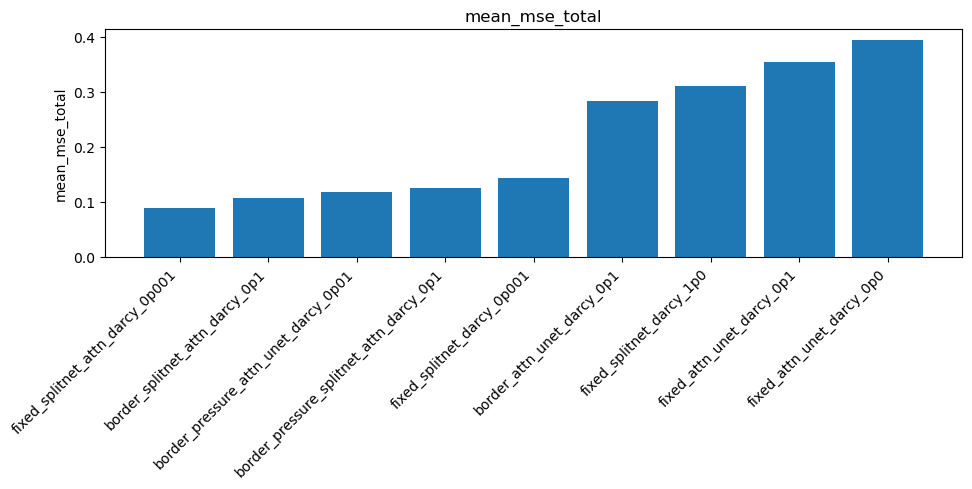

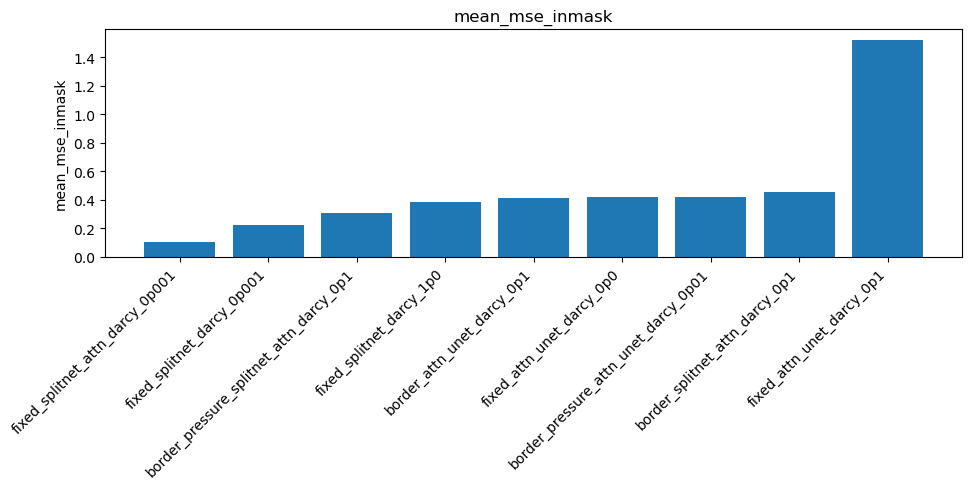

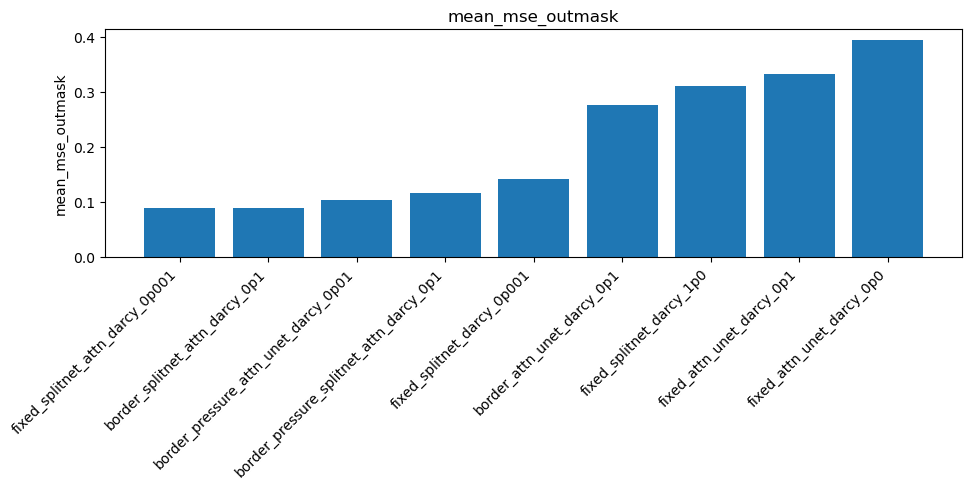

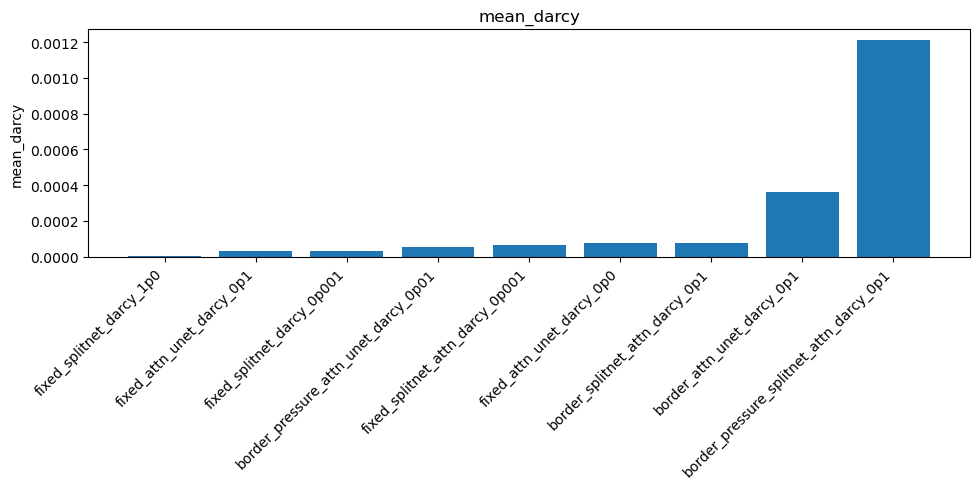

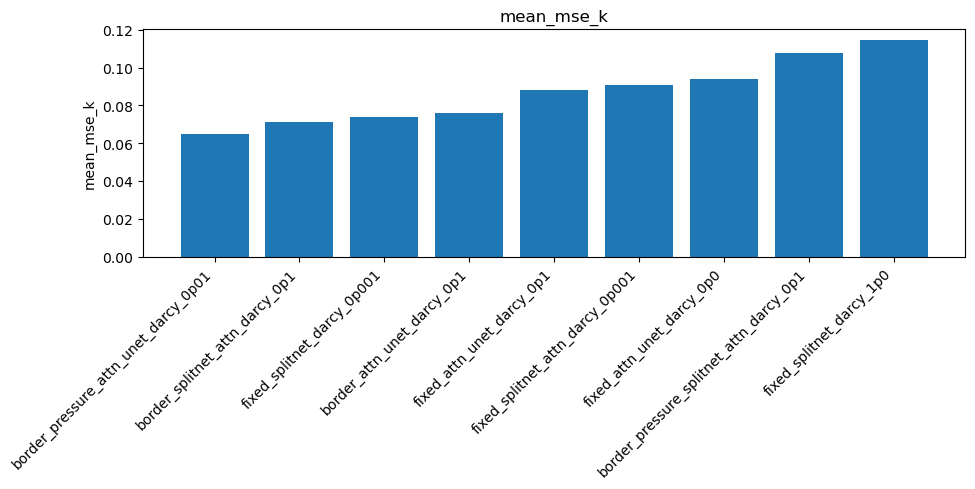

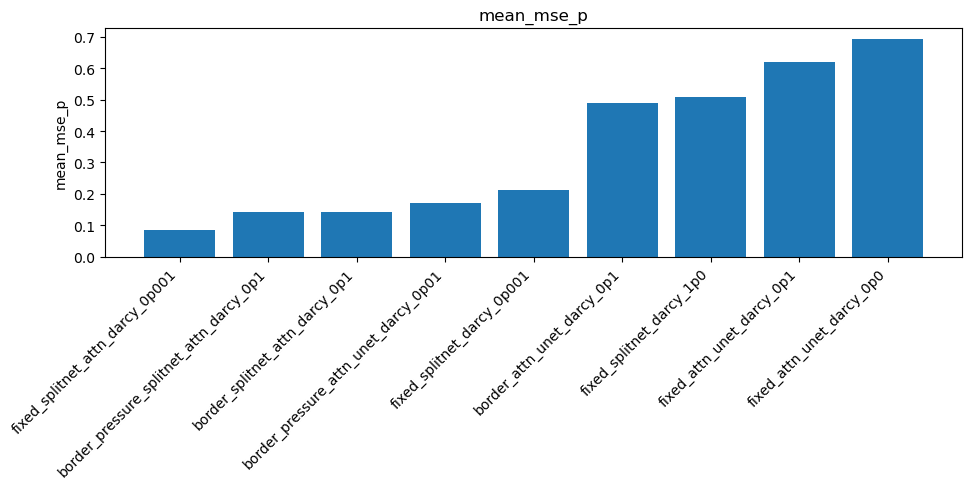

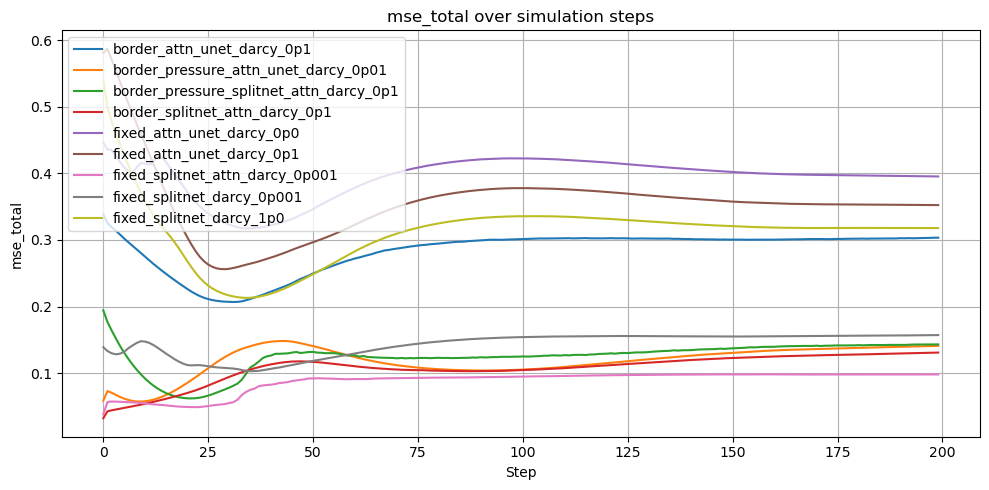

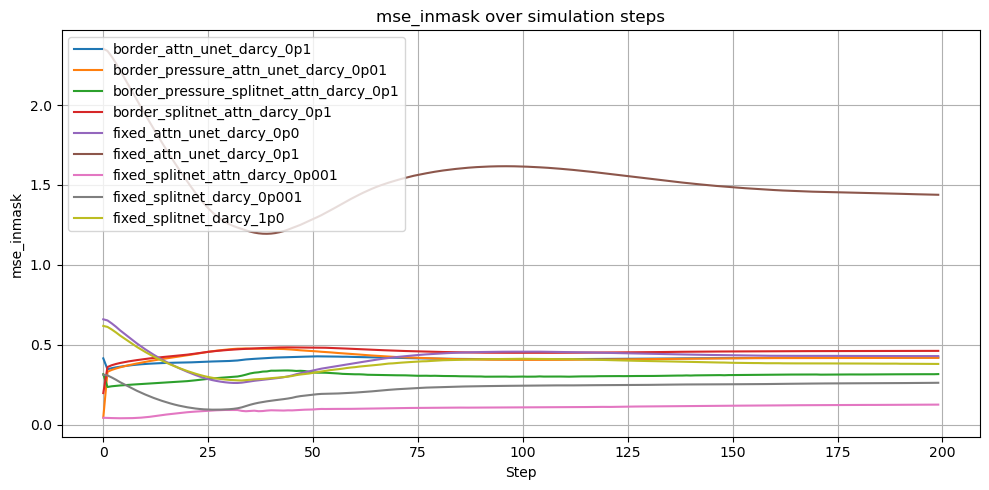

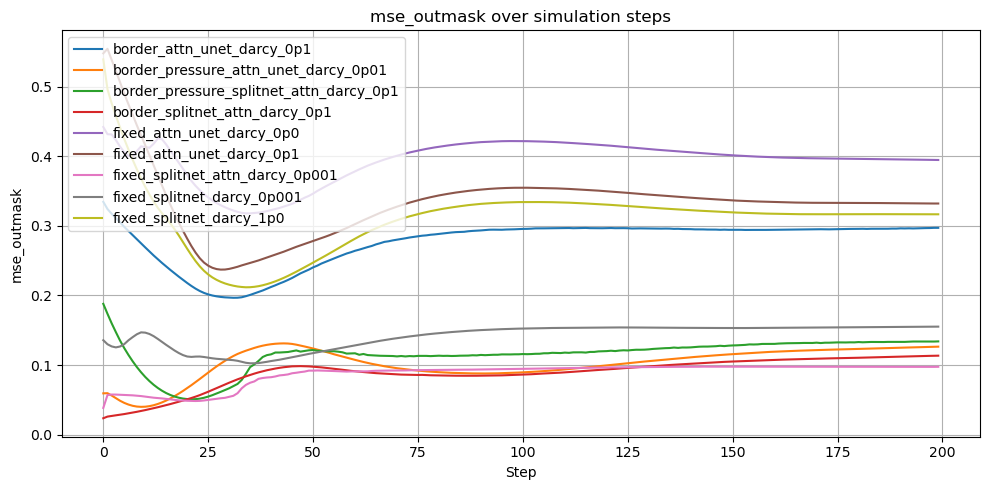

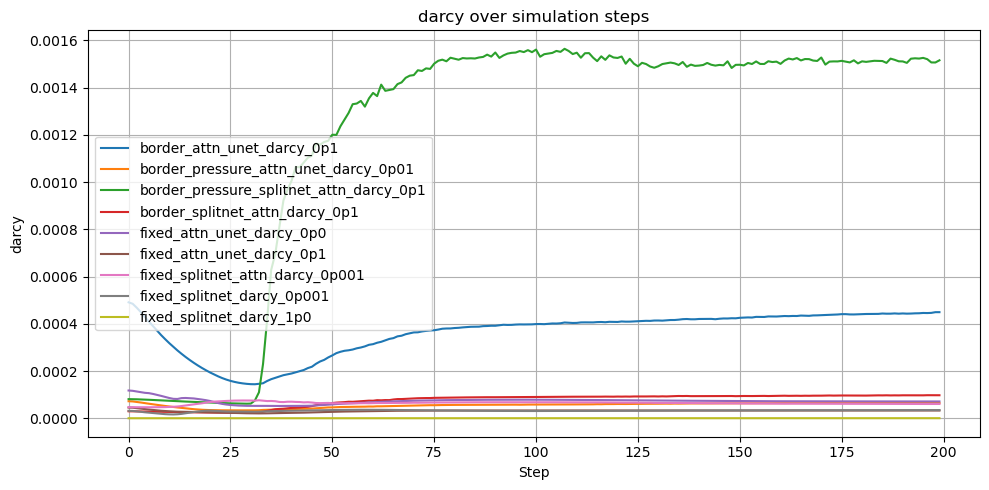

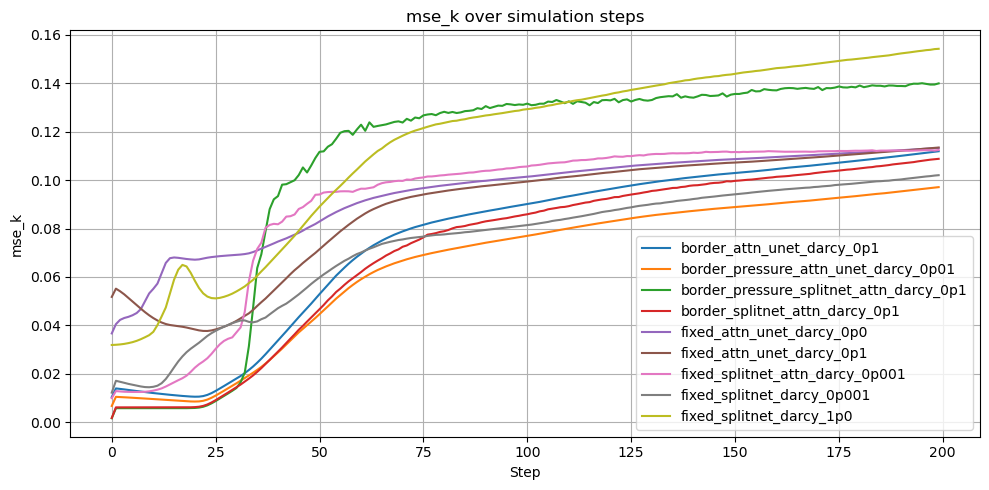

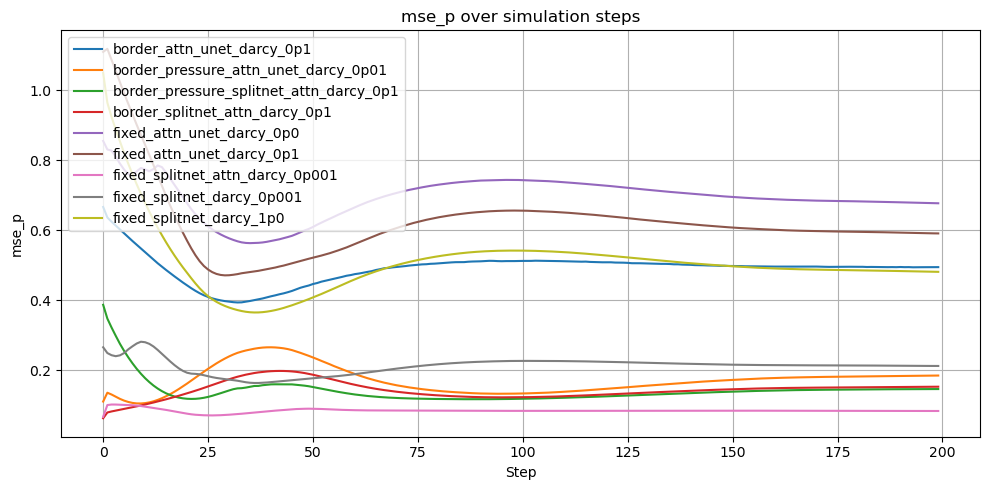

                                      name     model_type train_dataset_mode  \
6          fixed_splitnet_attn_darcy_0p001  splitnet_attn              fixed   
3           border_splitnet_attn_darcy_0p1  splitnet_attn             border   
1     border_pressure_attn_unet_darcy_0p01      attn_unet    border_pressure   
2  border_pressure_splitnet_attn_darcy_0p1  splitnet_attn    border_pressure   
7               fixed_splitnet_darcy_0p001       splitnet              fixed   
0               border_attn_unet_darcy_0p1      attn_unet             border   
8                 fixed_splitnet_darcy_1p0       splitnet              fixed   
5                fixed_attn_unet_darcy_0p1      attn_unet              fixed   
4                fixed_attn_unet_darcy_0p0      attn_unet              fixed   

     training_mode  darcy_weight  mean_mse_total  mean_mse_inmask  \
6  physics_limited         0.001        0.087678         0.103033   
3  physics_limited         0.100        0.107216         0.45

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------

def load_summary(summary_csv="test_eval_outputs/model_test_summary.csv"):
    return pd.read_csv(summary_csv)


def load_npz(npz_path):
    data = np.load(npz_path)
    return {k: data[k] for k in data.files}


def get_rows(summary_csv, model_names=None):
    df = load_summary(summary_csv)

    if model_names is None:
        return df

    if isinstance(model_names, str):
        model_names = [model_names]

    found = df[df["name"].isin(model_names)].copy()

    missing = sorted(set(model_names) - set(found["name"]))
    if missing:
        print("Missing models:")
        for m in missing:
            print("  -", m)

    return found


# -----------------------------------------------------------------------------
# Compact table comparison
# -----------------------------------------------------------------------------

def compare_table(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    sort_by="mean_mse_total",
):
    df = get_rows(summary_csv, model_names)

    cols = [
        "name",
        "model_type",
        "train_dataset_mode",
        "training_mode",
        "darcy_weight",
        "eval_dataset_mode",
        "mean_mse_total",
        "mean_nmse_total",
        "mean_darcy",
        "mean_mse_inmask",
        "mean_mse_outmask",
        "mean_mse_k",
        "mean_mse_p",
        "mean_mae_total",
        "mean_bias_total",
    ]

    cols = [c for c in cols if c in df.columns]
    out = df[cols].copy()

    if sort_by in out.columns:
        out = out.sort_values(sort_by)

    return out


# -----------------------------------------------------------------------------
# Bar plots from summary CSV
# -----------------------------------------------------------------------------

def plot_summary_metric(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    metric="mean_mse_total",
    sort=True,
):
    df = get_rows(summary_csv, model_names)

    if sort and metric in df.columns:
        df = df.sort_values(metric)

    plt.figure(figsize=(max(9, len(df) * 1.1), 5))
    plt.bar(df["name"], df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(metric)
    plt.tight_layout()
    plt.show()


def plot_core_summary(summary_csv="test_eval_outputs/model_test_summary.csv", model_names=None):
    metrics = [
        "mean_mse_total",
        "mean_mse_inmask",
        "mean_mse_outmask",
        "mean_darcy",
        "mean_mse_k",
        "mean_mse_p",
    ]

    for metric in metrics:
        plot_summary_metric(summary_csv, model_names, metric=metric)


# -----------------------------------------------------------------------------
# Step/time curve plots from NPZ
# -----------------------------------------------------------------------------

def mean_over_types_and_sims(arr):
    """
    Phase 1 arrays are shaped [types, sims, steps].
    This returns one curve over steps.
    """
    return np.nanmean(arr, axis=(0, 1))


def plot_metric_over_steps(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    metric="mse_total",
):
    df = get_rows(summary_csv, model_names)

    plt.figure(figsize=(10, 5))

    for _, row in df.iterrows():
        data = load_npz(row["npz_path"])

        if metric not in data:
            print(f"Skipping {row['name']}: no metric {metric}")
            continue

        curve = mean_over_types_and_sims(data[metric])
        steps = np.arange(len(curve))

        plt.plot(steps, curve, label=row["name"])

    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(f"{metric} over simulation steps")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_core_step_curves(summary_csv="test_eval_outputs/model_test_summary.csv", model_names=None):
    metrics = [
        "mse_total",
        "mse_inmask",
        "mse_outmask",
        "darcy",
        "mse_k",
        "mse_p",
    ]

    for metric in metrics:
        plot_metric_over_steps(summary_csv, model_names, metric=metric)


# -----------------------------------------------------------------------------
# Compare one metric split by model groups
# -----------------------------------------------------------------------------

def plot_grouped_by_darcy(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_type=None,
    train_dataset_mode=None,
    metric="mean_mse_total",
):
    df = load_summary(summary_csv)

    if model_type is not None:
        df = df[df["model_type"] == model_type]

    if train_dataset_mode is not None:
        df = df[df["train_dataset_mode"] == train_dataset_mode]

    df = df.sort_values("darcy_weight")

    plt.figure(figsize=(8, 5))
    plt.plot(df["darcy_weight"], df[metric], marker="o")
    plt.xscale("symlog", linthresh=0.001)
    plt.xlabel("Darcy weight")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Darcy weight")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df[["name", "model_type", "train_dataset_mode", "darcy_weight", metric]]



def rebuild_summary_csv_from_jsons(
    results_dir="test_eval_outputs",
    out_csv="test_eval_outputs/model_test_summary.csv",
):
    rows = []

    for path in Path(results_dir).glob("eval_*_summary.json"):
        with open(path, "r") as f:
            summary = json.load(f)

        config = summary.get("config", {})

        row = {
            "name": config.get("name", path.stem.replace("eval_", "").replace("_summary", "")),
            "model_type": config.get("model_type"),
            "train_dataset_mode": config.get("train_dataset_mode"),
            "training_mode": config.get("training_mode"),
            "darcy_weight": config.get("darcy_weight"),
            "eval_dataset_mode": config.get("eval_dataset_mode"),
            "model_path": config.get("model_path"),
            "npz_path": summary.get("npz_path"),
            "mean_mse_total": summary.get("mean_mse_total"),
            "mean_nmse_total": summary.get("mean_nmse_total"),
            "mean_darcy": summary.get("mean_darcy"),
            "mean_mse_inmask": summary.get("mean_mse_inmask"),
            "mean_mse_outmask": summary.get("mean_mse_outmask"),
            "mean_mse_k": summary.get("mean_mse_k"),
            "mean_mse_p": summary.get("mean_mse_p"),
            "mean_mae_total": summary.get("mean_mae_total"),
            "mean_bias_total": summary.get("mean_bias_total"),
        }

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("name")
    df.to_csv(out_csv, index=False)
    print(f"Saved rebuilt summary CSV with {len(df)} models: {out_csv}")
    return df


# -----------------------------------------------------------------------------
# Best model finder
# -----------------------------------------------------------------------------

def rank_models(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    metric="mean_mse_total",
    ascending=True,
    top_n=10,
):
    df = get_rows(summary_csv, model_names)

    cols = [
        "name",
        "model_type",
        "train_dataset_mode",
        "training_mode",
        "darcy_weight",
        metric,
        "mean_mse_inmask",
        "mean_mse_outmask",
        "mean_darcy",
    ]

    cols = [c for c in cols if c in df.columns]

    return df[cols].sort_values(metric, ascending=ascending).head(top_n)


# -----------------------------------------------------------------------------
# Example usage
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    summary_csv = "test_eval_outputs/model_test_summary.csv"

    rebuild_summary_csv_from_jsons(
        results_dir="test_eval_outputs",
        out_csv=summary_csv,
    )

    models_to_compare = [
        "border_attn_unet_darcy_0p1",
        "border_pressure_attn_unet_darcy_0p01",
        "border_pressure_splitnet_attn_darcy_0p1",
        "border_splitnet_attn_darcy_0p1",
        "fixed_attn_unet_darcy_0p0",
        "fixed_attn_unet_darcy_0p1",
        "fixed_splitnet_attn_darcy_0p001",
        "fixed_splitnet_darcy_0p001",
        "fixed_splitnet_darcy_1p0",
    ]

    print(compare_table(summary_csv, models_to_compare))
    plot_core_summary(summary_csv, models_to_compare)
    plot_core_step_curves(summary_csv, models_to_compare)
    print(rank_models(summary_csv, models_to_compare, metric="mean_mse_total"))